#**Name:** **Sri Harshanadh Reddy Chinthala**
#**Net ID:** **sxc230019**

# **1. US Exports Treemap Visualization (2022)**
## Data Visualization Assignment

**Objective:** Create an interactive treemap of United States exports using real-world trade data.

**Data Source:** Observatory of Economic Complexity (OEC) — BACI International Trade Database  
**Link** https://oec.world/en \
**Year:** 2022  




## Step 1: Install Required Libraries

We need:
- **pandas** — data manipulation and cleaning
- **plotly** — interactive treemap visualization
- **urllib / json** — fetching data from the OEC API

In [1]:
# Install plotly if not already installed
!pip install plotly pandas --quiet
print("Libraries installed successfully!")

Libraries installed successfully!


## Step 2: Import Libraries

In [2]:
import pandas as pd
import json
import urllib.request
import plotly.express as px

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 3: Fetch Real Export Data from OEC API

I used the **Observatory of Economic Complexity (OEC)** public API to fetch US export data.

- **Cube:** `trade_i_baci_a_92` (BACI trade data, HS 1992 classification)
- **Drilldowns:** Year, HS2-digit commodity level (with parent Sections)
- **Measures:** Trade Value (in USD)
- **Filter:** Exporter = United States, Year = 2022

In [3]:
# OEC API endpoint for US exports at HS2 level with parent sections
api_url = (
    "https://oec.world/olap-proxy/data.jsonrecords?"
    "cube=trade_i_baci_a_92"
    "&drilldowns=Year,HS2"
    "&measures=Trade+Value"
    "&parents=true"
    "&Year=2022"
    "&Exporter+Country=nausa"
)

# Fetch the data
print("Fetching US export data from OEC API...")
req = urllib.request.Request(api_url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(req, timeout=30) as response:
    raw_data = json.loads(response.read().decode())

# Convert to DataFrame
df_raw = pd.DataFrame(raw_data["data"])
print(f" Successfully fetched {len(df_raw)} records")
print(f"\nColumns available: {list(df_raw.columns)}")
df_raw.head()

Fetching US export data from OEC API...
 Successfully fetched 96 records

Columns available: ['Year', 'Section ID', 'Section', 'HS2 ID', 'HS2', 'Trade Value']


,Year,Section ID,Section,HS2 ID,HS2,Trade Value
0,2022,1,Animal Products,101,Live animals,1244816093
1,2022,1,Animal Products,102,Meat & edible offal,23137863914
2,2022,1,Animal Products,103,"Fish, Crustaceans & Molluscs",5284939086
3,2022,1,Animal Products,104,"Edible products of animal origin, n.e.s.",7562550522
4,2022,1,Animal Products,105,"Animal originated products, n.e.s.",1561203788


## Step 4: Data Cleaning & Preparation

In this step we:
1. Select only the relevant columns (Section, HS2 commodity name, Trade Value)
2. Remove any records with zero or missing trade values
3. Convert trade values from USD to Billions USD for readability
4. Truncate long commodity names for better display in the treemap

In [4]:
# Select relevant columns
df = df_raw[["Section", "HS2", "Trade Value"]].copy()
df.columns = ["sector", "commodity", "value_usd"]

# Remove zero/null values
df = df[df["value_usd"] > 0].copy()
print(f"Records after removing zeros: {len(df)}")

# Convert to billions
df["value_billions"] = df["value_usd"] / 1e9

# Create clean labels (truncate long names)
df["label"] = df["commodity"].apply(lambda x: x[:45] + "…" if len(x) > 45 else x)

# Sort by value
df = df.sort_values("value_billions", ascending=False).reset_index(drop=True)

print(f"\nTotal US Exports (2022): ${df['value_billions'].sum():.1f} Billion")
print(f"Number of commodity categories: {len(df)}")
print(f"Number of sectors: {df['sector'].nunique()}")
print(f"\n--- Top 15 US Exports ---")
df[["sector", "commodity", "value_billions"]].head(15)

Records after removing zeros: 96

Total US Exports (2022): $1953.2 Billion
Number of commodity categories: 96
Number of sectors: 21

--- Top 15 US Exports ---


,sector,commodity,value_billions
0,Mineral Products,"Mineral Fuels, Oils, Waxes, and its Distillate...",414.994653
1,Machines,"Machinery, mechanical appliances, & parts",250.506171
2,Machines,Electrical machinery and electronics,154.063785
3,Transportation,"Cars, tractors, trucks & parts thereof.",135.613936
4,Instruments,"Optical, photo, & film equipment; medical inst...",102.092917
5,Chemical Products,Pharmaceutical products,97.533224
6,Plastics and Rubbers,Plastics & articles thereof,95.783430
7,Precious Metals,"Precious stones, metals, & pearls",71.814671
8,Transportation,Aircraft and Spacecraft,56.232956
9,Chemical Products,Organic chemicals,50.424333


## Step 5: Explore the Data

Let's look at the sector-level breakdown before building the treemap.

In [5]:
# Aggregate by sector
sector_summary = (
    df.groupby("sector")["value_billions"]
    .agg(["sum", "count"])
    .sort_values("sum", ascending=False)
    .rename(columns={"sum": "Total ($ Billions)", "count": "# Commodities"})
)
sector_summary["Total ($ Billions)"] = sector_summary["Total ($ Billions)"].round(1)
sector_summary["% of Total"] = (sector_summary["Total ($ Billions)"] / sector_summary["Total ($ Billions)"].sum() * 100).round(1)

print("US Exports by Sector (2022)\n")
sector_summary

US Exports by Sector (2022)



,Total ($ Billions),# Commodities,% of Total
sector,,,
Mineral Products,431.3,3,22.1
Machines,404.6,2,20.7
Chemical Products,245.8,11,12.6
Transportation,198.1,4,10.1
Plastics and Rubbers,110.3,2,5.6
Instruments,104.0,3,5.3
Vegetable Products,92.0,9,4.7
Metals,84.3,11,4.3
Precious Metals,71.8,1,3.7


## Step 6: Create the Interactive Treemap

We use **Plotly Express** `treemap` to create a hierarchical, interactive visualization:

- **Hierarchy:** Sector → Commodity (2 levels)
- **Size:** Trade value in billions USD
- **Color:** Sector (categorical)
- **Interactivity:** Hover for details, click to zoom into sectors

### Why Treemap?
* Shows **part-to-whole** relationships with hierarchy  
* Easily compare sizes across 96 commodities  
* Reveals which sectors and products dominate US exports

In [6]:
# Define a custom color palette for sectors
sectors_sorted = sorted(df["sector"].unique())
palette = [
    "#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261",
    "#6A4C93", "#1D3557", "#264653", "#D62828", "#003049",
    "#606C38", "#DDA15E", "#BC6C25", "#283618", "#8ECAE6",
    "#023047", "#FFB703", "#FB8500", "#219EBC", "#126782", "#4361EE"
]
color_map = {s: palette[i % len(palette)] for i, s in enumerate(sectors_sorted)}

# Create the treemap
fig = px.treemap(
    df,
    path=["sector", "label"],        # Hierarchy: Sector → Commodity
    values="value_billions",          # Size = export value
    color="sector",                   # Color by sector
    color_discrete_map=color_map,
    title=(
        "<b>United States Exports by Sector & Commodity (2022)</b>"
        "<br><sup>Source: Observatory of Economic Complexity (OEC) / BACI | Values in Billions USD</sup>"
    ),
)

# Customize text and hover
fig.update_traces(
    textinfo="label+value+percent parent",
    texttemplate="<b>%{label}</b><br>$%{value:.1f}B<br>%{percentParent:.1%}",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Export Value: $%{value:.2f}B<br>"
        "Share of sector: %{percentParent:.1%}"
        "<extra></extra>"
    ),
    marker=dict(cornerradius=5),
)

# Layout
fig.update_layout(
    font=dict(family="Arial, sans-serif", size=12),
    title_font_size=20,
    margin=dict(t=80, l=10, r=10, b=10),
    width=1200,
    height=750,
)

fig.show()

## Step 7: Key Findings
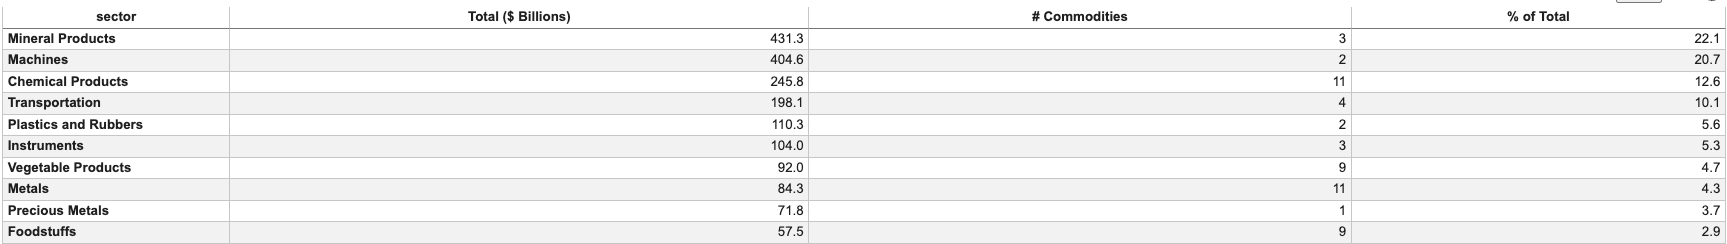

### Observations:

- **Mineral fuels** is the single largest commodity export at $415 B, reflecting the US shale oil boom.

- **Machinery & Electronics** ($404.6 B) together rival mineral fuels, showing US strength in high-tech manufacturing.

- **Pharmaceuticals** ($97.5B) highlight the US role in global healthcare.

- The treemap's hierarchical view makes it easy to see how individual commodities contribute within each sector.






# **2. Global Energy Consumption Sunburst Diagram (2023)**

## Business Use Case: Energy Transition Intelligence

**Why this matters:** As the world races toward net-zero emissions, energy companies, policymakers, and ESG investors need to understand how each country's energy mix is composed, not just total consumption, but the **proportion of fossil fuels vs. renewables**.

This sunburst diagram reveals the **hierarchical structure of global energy consumption**:
- **Center** → World Total (~580,000+ TWh)
- **Inner Ring** → Continents/Regions
- **Middle Ring** → Top consuming countries
- **Outer Ring** → Energy sources (Oil, Gas, Coal, Nuclear, Hydro, Solar, Wind, Biofuel)

**Data Source:** [Our World in Data – Energy Dataset](https://github.com/owid/energy-data) (2023, latest complete year)

**Key Questions Answered:**
1. Which continents are most dependent on fossil fuels?
2. Which countries lead in renewable energy adoption?
3. How does the energy mix differ between developed and developing nations?


## Step 1: Install Dependencies & Import Libraries

In [7]:
# Install required packages
!pip install plotly pandas --quiet

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import urllib.request
import io
print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Data Acquisition

We fetch the comprehensive energy dataset from **Our World in Data** (OWID), which aggregates data from:
- BP Statistical Review of World Energy
- Ember (electricity data)
- UN, EIA, and other official sources

This dataset covers **200+ countries** from 1900–2023 with 100+ energy indicators.


In [8]:
# Fetch data directly from Our World in Data GitHub repository
url = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
print("Fetching global energy data from Our World in Data...")
df_raw = pd.read_csv(url)
print(f"Loaded {len(df_raw):,} rows × {len(df_raw.columns)} columns")
print(f"Year range: {df_raw['year'].min()} – {df_raw['year'].max()}")
print(f"Countries/Regions: {df_raw['country'].nunique()}")
df_raw.head()

Fetching global energy data from Our World in Data...
Loaded 23,232 rows × 130 columns
Year range: 1900 – 2025
Countries/Regions: 314


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


## Step 3: Data Cleaning & Filtering

We filter for **2022** (latest complete year) and select the **top 25 energy-consuming countries** to keep the sunburst readable. We extract 8 energy sources measured in **TWh (Terawatt-hours)**.

In [9]:
# Energy source columns (all in TWh)
energy_cols = {
    'oil_consumption': '🛢️ Oil',
    'gas_consumption': '🔥 Natural Gas',
    'coal_consumption': '⛏️ Coal',
    'nuclear_consumption': '⚛️ Nuclear',
    'hydro_consumption': '💧 Hydropower',
    'solar_consumption': '☀️ Solar',
    'wind_consumption': '🌬️ Wind',
    'biofuel_consumption': '🌿 Biofuel'
}

# Filter: year 2023, real countries only (have iso_code, exclude aggregates)
df = df_raw[(df_raw['year'] == 2023) & (df_raw['iso_code'].notna())].copy()

# Remove aggregate regions (like 'World', 'Asia', etc.)
aggregates = ['OWID_WRL', 'OWID_AFR', 'OWID_ASI', 'OWID_EUR', 'OWID_NAM', 'OWID_SAM', 'OWID_OCE',
              'OWID_HIC', 'OWID_LIC', 'OWID_LMC', 'OWID_UMC', 'OWID_EUN', 'OWID_CIS', 'OWID_USS']
df = df[~df['iso_code'].isin(aggregates)]

# Calculate total consumption per country
df['total_energy'] = df[list(energy_cols.keys())].fillna(0).sum(axis=1)

# Take top 25 by total consumption
df_top = df.nlargest(25, 'total_energy').copy()
print(f"Filtered to top {len(df_top)} countries by energy consumption (2022)")
print(f"Total energy covered: {df_top['total_energy'].sum():,.0f} TWh")
print(f"\n📊 Top 10 countries:")
print(df_top[['country', 'total_energy']].head(10).to_string(index=False))

Filtered to top 25 countries by energy consumption (2022)
Total energy covered: 140,307 TWh

📊 Top 10 countries:
      country  total_energy
        China     45988.441
United States     25827.142
        India     10696.677
       Russia      8713.807
        Japan      4693.850
       Canada      3786.842
         Iran      3591.757
       Brazil      3577.790
  South Korea      3482.062
 Saudi Arabia      3199.992


## Step 4: Data Transformation — Build Hierarchy

Assigned each country to its **continent** to create the 3-level hierarchy:
`World → Continent → Country → Energy Source`

Then "melt" the data from wide format to long format for Plotly's sunburst.


In [20]:
# Map countries to continents
continent_map = {
    'China': 'Asia', 'India': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia',
    'Indonesia': 'Asia', 'Saudi Arabia': 'Asia', 'Iran': 'Asia', 'Thailand': 'Asia',
    'Taiwan': 'Asia', 'Malaysia': 'Asia', 'Pakistan': 'Asia', 'Vietnam': 'Asia',
    'United Arab Emirates': 'Asia', 'Iraq': 'Asia', 'Turkey': 'Asia',
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Brazil': 'South America', 'Argentina': 'South America',
    'Germany': 'Europe', 'France': 'Europe', 'United Kingdom': 'Europe',
    'Italy': 'Europe', 'Spain': 'Europe', 'Poland': 'Europe', 'Netherlands': 'Europe',
    'Russia': 'Europe', 'Ukraine': 'Europe',
    'South Africa': 'Africa', 'Egypt': 'Africa', 'Nigeria': 'Africa', 'Algeria': 'Africa',
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}

df_top['continent'] = df_top['country'].map(continent_map).fillna('Other')

# Melt to long format: one row per country-energy_source
df_melted = df_top.melt(
    id_vars=['country', 'continent'],
    value_vars=list(energy_cols.keys()),
    var_name='source_key',
    value_name='twh'
)

# Map to readable labels
df_melted['energy_source'] = df_melted['source_key'].map(energy_cols)
df_melted['twh'] = df_melted['twh'].fillna(0)

# Remove zero/negligible entries for cleaner visual
df_melted = df_melted[df_melted['twh'] > 5].copy()

# Classify as fossil vs renewable
fossil = ['🛢️ Oil', '🔥 Natural Gas', '⛏️ Coal']
df_melted['type'] = df_melted['energy_source'].apply(lambda x: 'Fossil Fuel' if x in fossil else 'Clean Energy')

print(f"Transformed data: {len(df_melted):,} records")
print(f"\nFossil vs Clean breakdown:")
print(df_melted.groupby('type')['twh'].sum().apply(lambda x: f"{x:,.0f} TWh"))
df_raw.iloc[15005:15015]

Transformed data: 170 records

Fossil vs Clean breakdown:
type
Clean Energy     23,114 TWh
Fossil Fuel     117,158 TWh
Name: twh, dtype: object


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
15005,Norway,1963,NOR,3666497.0,4.664939e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15006,Norway,1964,NOR,3694319.0,4.897216e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15007,Norway,1965,NOR,3723173.0,5.157312e+10,NaN,NaN,0.0,0.0,NaN,...,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0
15008,Norway,1966,NOR,3752788.0,5.351923e+10,NaN,0.0,0.0,0.0,NaN,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0
15009,Norway,1967,NOR,3784111.0,5.686601e+10,NaN,0.0,0.0,0.0,NaN,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0
15010,Norway,1968,NOR,3816089.0,5.814020e+10,NaN,0.0,0.0,0.0,NaN,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0
15011,Norway,1969,NOR,3847304.0,6.076457e+10,NaN,0.0,0.0,0.0,NaN,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0
15012,Norway,1970,NOR,3875351.0,6.197226e+10,NaN,0.0,0.0,0.0,NaN,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0
15013,Norway,1971,NOR,3902754.0,6.514953e+10,NaN,0.0,0.0,0.0,NaN,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0
15014,Norway,1972,NOR,3932913.0,6.846967e+10,NaN,0.0,0.0,0.0,NaN,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0


## Step 5: Exploratory Data Summary

Before building the sunburst, let's examine the continental energy breakdown.


In [12]:
# Summary by continent
continent_summary = df_melted.groupby('continent')['twh'].sum().sort_values(ascending=False)
print("Energy Consumption by Continent (TWh):")
print("=" * 45)
for cont, val in continent_summary.items():
    pct = val / continent_summary.sum() * 100
    bar = '█' * int(pct / 2)
    print(f"  {cont:<20} {val:>10,.0f} TWh  ({pct:4.1f}%) {bar}")

print(f"\n{'─' * 45}")
print(f"  {'TOTAL':<20} {continent_summary.sum():>10,.0f} TWh")

# Fossil vs Clean by continent
print("\n\n⚡ Fossil vs Clean Energy by Continent:")
print("=" * 55)
pivot = df_melted.pivot_table(values='twh', index='continent', columns='type', aggfunc='sum', fill_value=0)
pivot['Renewable %'] = (pivot.get('Clean Energy', 0) / (pivot.sum(axis=1)) * 100)
pivot = pivot.sort_values('Renewable %', ascending=False)
print(pivot.round(1).to_string())

Energy Consumption by Continent (TWh):
  Asia                     82,870 TWh  (59.1%) █████████████████████████████
  North America            31,876 TWh  (22.7%) ███████████
  Europe                   18,960 TWh  (13.5%) ██████
  South America             3,578 TWh  ( 2.6%) █
  Oceania                   1,632 TWh  ( 1.2%) 
  Africa                    1,357 TWh  ( 1.0%) 

─────────────────────────────────────────────
  TOTAL                   140,272 TWh


⚡ Fossil vs Clean Energy by Continent:
type           Clean Energy  Fossil Fuel  Renewable %
continent                                            
South America        1694.6       1883.2         47.4
Europe               3936.8      15023.1         20.8
North America        6136.0      25740.3         19.2
Oceania               224.2       1407.3         13.7
Asia                11058.9      71811.0         13.3
Africa                 63.7       1293.3          4.7


## Step 6: Interactive Sunburst Diagram

The sunburst is built with **3 hierarchical levels**:
1. **Center**: World total energy
2. **Inner ring**: Continents
3. **Middle ring**: Countries
4. **Outer ring**: Individual energy sources

**Color** represents the energy source type, making it easy to spot fossil fuel dependence vs. clean energy adoption at a glance. **Click any segment** to drill down!


In [44]:
# Custom color mapping for energy sources
color_map = {
    '🛢️ Oil': '#1a1a2e',
    '🔥 Natural Gas': '#e94560',
    '⛏️ Coal': '#533a2d',
    '⚛️ Nuclear': '#7b2d8e',
    '💧 Hydropower': '#0077b6',
    '☀️ Solar': '#f4a261',
    '🌬️ Wind': '#2a9d8f',
    '🌿 Biofuel': '#4caf50'
}

fig = px.sunburst(
    df_melted,
    path=['continent', 'country', 'energy_source'],
    values='twh',
    color='energy_source',
    color_discrete_map=color_map,
    title='<b>🌍 Global Energy Consumption by Source (2022)</b><br><sup>Top 25 Countries · Click to Drill Down · Values in TWh</sup>',
    hover_data={'twh': ':,.1f'},
)

fig.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='radial',
    hovertemplate='<b>%{label}</b><br>Energy: %{value:,.1f} TWh<br>Share of parent: %{percentParent:.1%}<extra></extra>',
    maxdepth=3  # Show 3 levels by default
)

fig.update_layout(
    width=900,
    height=900,
    margin=dict(t=80, l=10, r=10, b=10),
    font=dict(family='Segoe UI, sans-serif', size=12),
    title_font_size=20,
    title_x=0.5,
    paper_bgcolor='#fafafa',
)

fig.show()
print("\n💡 Tip: Click on any continent or country segment to drill down into its energy mix!")


💡 Tip: Click on any continent or country segment to drill down into its energy mix!


## Step 7: Fossil vs. Clean Energy Sunburst

A second sunburst that groups energy sources into **Fossil Fuel** vs **Clean Energy** first, revealing the global energy transition gap.


In [13]:
# Second sunburst: Type → Source → Country
type_colors = {
    'Fossil Fuel': '#e63946',
    'Clean Energy': '#2a9d8f',
}

fig2 = px.sunburst(
    df_melted,
    path=['type', 'energy_source', 'country'],
    values='twh',
    color='type',
    color_discrete_map=type_colors,
    title='<b>⚡ Fossil Fuel vs Clean Energy Breakdown (2022)</b><br><sup>Global Top 25 Countries · Values in TWh</sup>',
)

fig2.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='radial',
    hovertemplate='<b>%{label}</b><br>Energy: %{value:,.1f} TWh<br>Share: %{percentParent:.1%}<extra></extra>',
)

fig2.update_layout(
    width=850, height=850,
    margin=dict(t=80, l=10, r=10, b=10),
    font=dict(family='Segoe UI, sans-serif', size=12),
    title_font_size=18, title_x=0.5,
    paper_bgcolor='#fafafa',
)
fig2.show()

# Print key insight
total = df_melted['twh'].sum()
fossil_pct = df_melted[df_melted['type']=='Fossil Fuel']['twh'].sum() / total * 100
print(f"\n Key Insight: Fossil fuels still account for {fossil_pct:.1f}% of energy consumption")
print(f"   among the world's top 25 energy-consuming nations.")


 Key Insight: Fossil fuels still account for 83.5% of energy consumption
   among the world's top 25 energy-consuming nations.


# **3. Dendogram: Hierarchical Clustering of Global Equities by Return Correlation (2024–2025)**

## Business Use Case: Portfolio Diversification & Risk Management

**Why this matters:** Quantitative portfolio managers at firms like BlackRock, Citadel, and Bridgewater use **hierarchical clustering on asset return correlations** to:
- Identify groups of stocks that move together (correlated risk)
- Build diversified portfolios by selecting assets from *different* clusters
- Detect regime changes when cluster structures shift over time
- Replace traditional sector classifications with **data-driven groupings**

This technique is known as **Hierarchical Risk Parity (HRP)**, introduced by Marcos López de Prado (Journal of Portfolio Management, 2016), and is now an industry-standard approach in quantitative finance.

**Data:** Daily stock returns for 35 major global companies across 10+ sectors, sourced from Yahoo Finance (Jan 2024 – Mar 2025).

---

## Step 1: Install & Import Libraries

In [14]:
# Install required packages (run once)
# !pip install yfinance scipy scikit-learn seaborn matplotlib pandas plotly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("All libraries imported successfully")

All libraries imported successfully


## Step 2: Data Acquisition — Fetching Real Stock Price Data

We fetch daily adjusted closing prices for **35 carefully selected global stocks** spanning Technology, Finance, Healthcare, Energy, Consumer, Industrials, and more.

Using the `yfinance` library to pull data directly from Yahoo Finance — a trusted, free, real-time financial data source.

In [15]:
import yfinance as yf

# 35 major global stocks across diverse sectors
tickers = {
    # US Tech Giants
    'AAPL': 'Apple', 'MSFT': 'Microsoft', 'GOOGL': 'Alphabet',
    'AMZN': 'Amazon', 'NVDA': 'NVIDIA', 'META': 'Meta',
    'TSLA': 'Tesla', 'CRM': 'Salesforce',
    # US Finance
    'JPM': 'JPMorgan', 'GS': 'Goldman Sachs', 'BAC': 'Bank of America',
    'V': 'Visa', 'MA': 'Mastercard',
    # US Healthcare
    'JNJ': 'Johnson & Johnson', 'UNH': 'UnitedHealth', 'PFE': 'Pfizer',
    'ABBV': 'AbbVie', 'MRK': 'Merck',
    # US Energy
    'XOM': 'ExxonMobil', 'CVX': 'Chevron', 'COP': 'ConocoPhillips',
    # US Consumer / Retail
    'WMT': 'Walmart', 'KO': 'Coca-Cola', 'PG': 'Procter & Gamble',
    'MCD': "McDonald's", 'NKE': 'Nike',
    # US Industrials
    'CAT': 'Caterpillar', 'BA': 'Boeing', 'UPS': 'UPS',
    'HON': 'Honeywell',
    # Semiconductors
    'AMD': 'AMD', 'INTC': 'Intel', 'AVGO': 'Broadcom',
    # Communication / Media
    'DIS': 'Disney', 'NFLX': 'Netflix', 'CMCSA': 'Comcast'
}

print(f"Fetching daily prices for {len(tickers)} stocks (Jan 2024 – Mar 2025)...")
data = yf.download(list(tickers.keys()), start='2024-01-01', end='2025-03-15', auto_adjust=True)

# Extract closing prices
prices = data['Close'] if 'Close' in data.columns.get_level_values(0) else data
prices = prices[list(tickers.keys())]  # Ensure column order
prices.columns = [f"{tickers[t]} ({t})" for t in prices.columns]

print(f"Downloaded {prices.shape[0]} trading days × {prices.shape[1]} stocks")
print(f"Date range: {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}")
prices.tail()

Fetching daily prices for 36 stocks (Jan 2024 – Mar 2025)...


[*********************100%***********************]  36 of 36 completed

Downloaded 301 trading days × 36 stocks
Date range: 2024-01-02 to 2025-03-14


,Apple (AAPL),Microsoft (MSFT),Alphabet (GOOGL),Amazon (AMZN),NVIDIA (NVDA),Meta (META),Tesla (TSLA),Salesforce (CRM),JPMorgan (JPM),Goldman Sachs (GS),...,Caterpillar (CAT),Boeing (BA),UPS (UPS),Honeywell (HON),AMD (AMD),Intel (INTC),Broadcom (AVGO),Disney (DIS),Netflix (NFLX),Comcast (CMCSA)
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-10,226.492844,377.271759,165.296829,194.539993,106.944962,595.600281,222.149994,271.129944,227.554092,520.869141,...,340.524475,148.149994,112.903488,197.296936,96.629997,19.930000,182.415512,101.952499,86.667999,32.503677
2025-03-11,219.881653,377.559540,163.473160,196.589996,108.724373,603.289551,230.580002,275.253021,224.535965,520.643860,...,335.158356,154.059998,108.916016,192.471100,96.760002,19.780001,187.993301,96.829155,89.510002,32.359657
2025-03-12,216.038422,380.358124,166.532547,198.889999,115.712730,617.084106,248.089996,282.734192,223.320877,524.836975,...,333.540588,158.800003,107.886391,190.404190,100.790001,20.680000,192.087631,97.679749,91.968002,31.675562
2025-03-13,208.770096,375.892334,162.197601,193.889999,115.552773,588.279663,240.679993,269.977448,220.665329,514.158264,...,328.786041,159.320007,107.858307,190.717941,98.110001,23.700001,189.249283,95.810417,89.016998,31.234497
2025-03-14,212.563568,385.607910,164.918152,197.949997,121.641335,605.710266,249.979996,277.587799,227.769669,530.421326,...,335.030121,161.809998,109.290428,193.283096,100.970001,24.049999,193.383179,97.561058,91.800003,31.891592


## Step 3: Data Cleaning & Preprocessing

We compute **daily log returns** (standard in quantitative finance) and handle any missing values. Log returns are preferred because they are:
- Additive over time
- More normally distributed than simple returns
- Standard practice in portfolio theory

In [21]:
# Compute daily log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Check for and handle missing data
missing = returns.isnull().sum()
if missing.sum() > 0:
    print(f"Found {missing.sum()} missing values — forward-filling")
    returns = returns.fillna(method='ffill').fillna(method='bfill')
else:
    print("No missing values in return series")

print(f"\nReturns matrix shape: {returns.shape}")
print(f"Period: {returns.index[0].strftime('%Y-%m-%d')} to {returns.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSummary Statistics (Annualized):")

summary = pd.DataFrame({
    'Ann. Return (%)': (returns.mean() * 252 * 100).round(1),
    'Ann. Volatility (%)': (returns.std() * np.sqrt(252) * 100).round(1),
    'Sharpe Ratio': ((returns.mean() * 252) / (returns.std() * np.sqrt(252))).round(2)
}).sort_values('Ann. Return (%)', ascending=False)

summary.head(10)

No missing values in return series

Returns matrix shape: (300, 36)
Period: 2024-01-03 to 2025-03-14

Summary Statistics (Annualized):


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio
NVIDIA (NVDA),77.9,56.2,1.39
Netflix (NFLX),56.5,31.3,1.81
Broadcom (AVGO),50.6,54.9,0.92
Meta (META),47.6,35.2,1.35
Walmart (WMT),40.9,19.9,2.05
Goldman Sachs (GS),30.3,26.8,1.13
JPMorgan (JPM),27.7,23.7,1.17
AbbVie (ABBV),27.4,23.8,1.15
Amazon (AMZN),23.3,28.1,0.83
Visa (V),21.6,17.1,1.27


## Step 4: Correlation Analysis — The Foundation of Clustering

We compute the **Pearson correlation matrix** of daily returns. Stocks with high correlation tend to move together — these will cluster closely in our dendrogram.

We then convert correlation to **distance**: `distance = √(2 × (1 - correlation))`

This is a proper metric distance that satisfies the triangle inequality, making it suitable for hierarchical clustering.

In [22]:
# Compute correlation matrix
corr_matrix = returns.corr()

# Convert correlation to distance: d = sqrt(2 * (1 - rho))
# This is a proper metric distance
dist_matrix = np.sqrt(2 * (1 - corr_matrix))

print("Correlation Matrix Shape:", corr_matrix.shape)
print(f"\nHighest correlation: {corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).max().max():.3f}")
print(f"Lowest correlation:  {corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).min().min():.3f}")
print(f"Mean correlation:    {corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).mean().mean():.3f}")

Correlation Matrix Shape: (36, 36)

Highest correlation: 0.789
Lowest correlation:  -0.420
Mean correlation:    0.198


## Step 5: Hierarchical Clustering & Dendrogram

We apply **Ward's linkage method** — the most widely used in practice because it minimizes within-cluster variance and produces compact, interpretable clusters.

### Main Dendrogram — Full View

In [23]:
# Convert distance matrix to condensed form for scipy
condensed_dist = squareform(dist_matrix.values)

# Compute linkage matrix using Ward's method
Z = linkage(condensed_dist, method='ward')

# Determine optimal number of clusters (using elbow in merge distances)
merge_distances = Z[:, 2]
accel = np.diff(merge_distances, 2)
optimal_k = len(merge_distances) - np.argmax(accel) - 1
optimal_k = max(4, min(optimal_k, 8))  # Keep between 4-8 clusters
cut_threshold = Z[-(optimal_k), 2]

print(f"Optimal number of clusters: {optimal_k}")
print(f"Cut threshold distance: {cut_threshold:.2f}")

# Assign cluster labels
cluster_labels = fcluster(Z, t=optimal_k, criterion='maxclust')
stock_clusters = pd.DataFrame({
    'Stock': corr_matrix.columns,
    'Cluster': cluster_labels
}).sort_values('Cluster')

print(f"\nCluster Assignments:")
for c in sorted(stock_clusters['Cluster'].unique()):
    members = stock_clusters[stock_clusters['Cluster'] == c]['Stock'].tolist()
    print(f"  Cluster {c} ({len(members)} stocks): {', '.join(members)}")

Optimal number of clusters: 4
Cut threshold distance: 1.70

Cluster Assignments:
  Cluster 1 (9 stocks): Microsoft (MSFT), Alphabet (GOOGL), Amazon (AMZN), NVIDIA (NVDA), Salesforce (CRM), Meta (META), AMD (AMD), Broadcom (AVGO), Netflix (NFLX)
  Cluster 2 (7 stocks): Coca-Cola (KO), Merck (MRK), McDonald's (MCD), AbbVie (ABBV), Pfizer (PFE), Procter & Gamble (PG), Johnson & Johnson (JNJ)
  Cluster 3 (3 stocks): ConocoPhillips (COP), Chevron (CVX), ExxonMobil (XOM)
  Cluster 4 (17 stocks): Mastercard (MA), Goldman Sachs (GS), JPMorgan (JPM), Bank of America (BAC), Visa (V), UnitedHealth (UNH), Walmart (WMT), Caterpillar (CAT), Nike (NKE), Boeing (BA), UPS (UPS), Apple (AAPL), Tesla (TSLA), Intel (INTC), Honeywell (HON), Disney (DIS), Comcast (CMCSA)


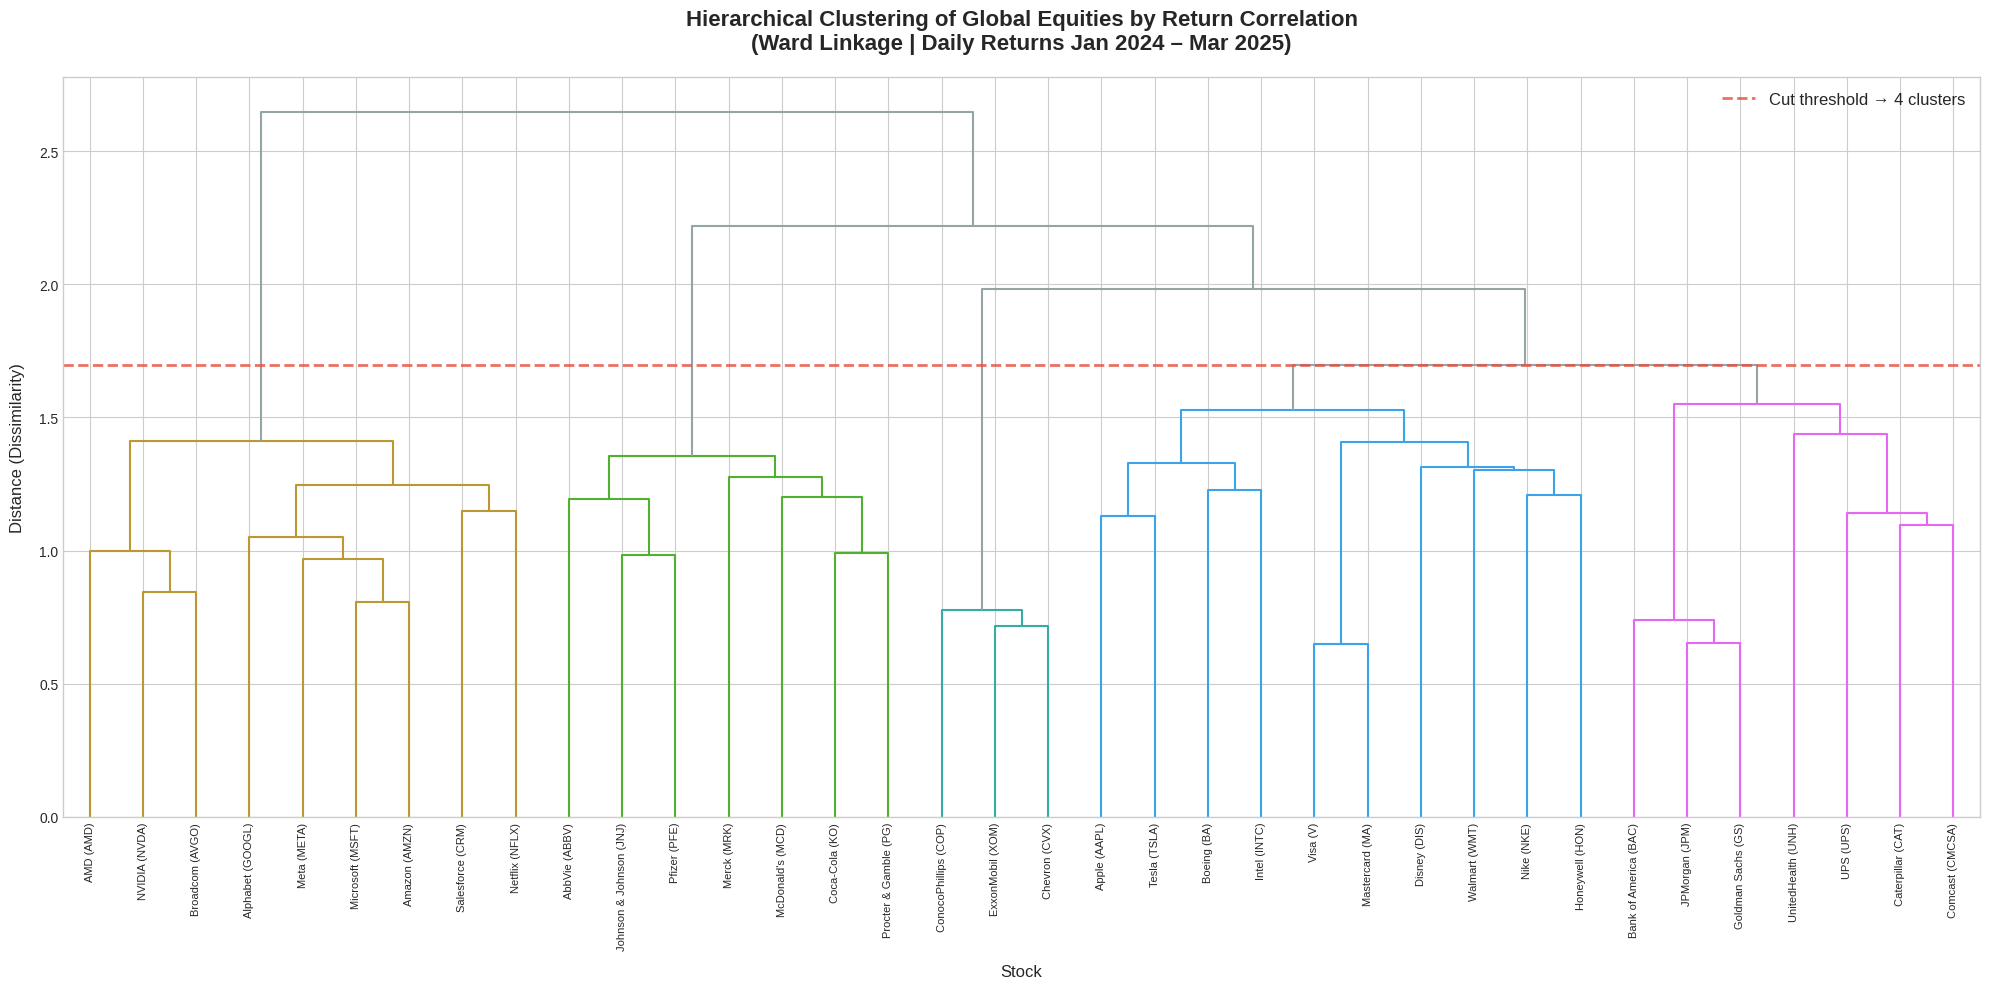

Dendrogram saved as Dendrogram_Global_Equities.png


In [24]:
# === MAIN DENDROGRAM ===
fig, ax = plt.subplots(figsize=(20, 10))

# Color palette for clusters
cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

dend = dendrogram(
    Z,
    labels=corr_matrix.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=cut_threshold,
    above_threshold_color='#95a5a6',
    ax=ax
)

# Add cut line
ax.axhline(y=cut_threshold, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Cut threshold → {optimal_k} clusters')

ax.set_title('Hierarchical Clustering of Global Equities by Return Correlation\n(Ward Linkage | Daily Returns Jan 2024 – Mar 2025)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Stock', fontsize=12, labelpad=10)
ax.set_ylabel('Distance (Dissimilarity)', fontsize=12, labelpad=10)
ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.savefig('Dendrogram_Global_Equities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dendrogram saved as Dendrogram_Global_Equities.png")

## Step 6: Clustermap — Correlation Heatmap with Dendrograms

This combines the **correlation heatmap** with **dendrograms on both axes**, showing how the hierarchical clustering reorganizes stocks to reveal block-diagonal structure — a hallmark of well-separated clusters.

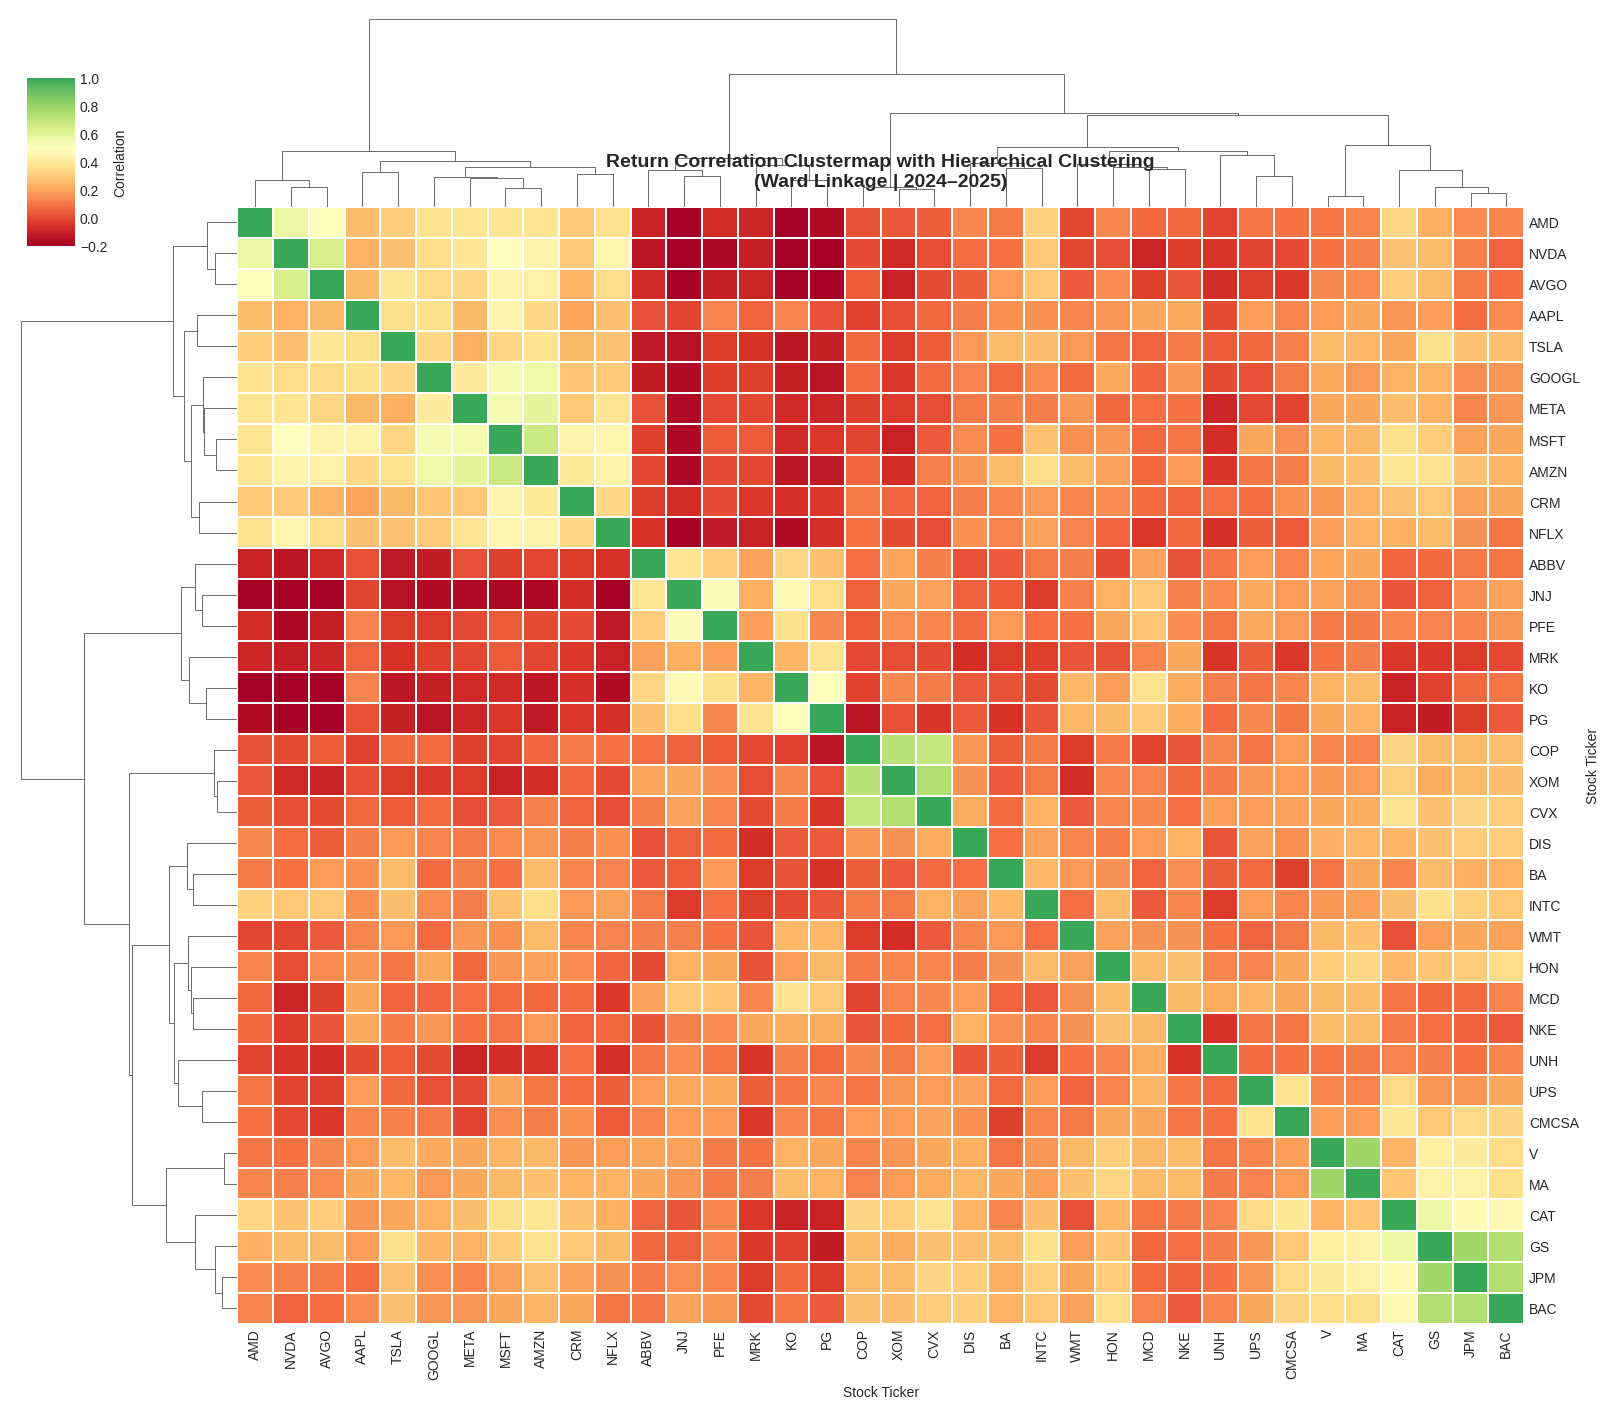

Clustermap saved as Clustermap_Global_Equities.png


In [25]:
# === CLUSTERMAP: Heatmap + Dendrogram Combined ===
# Use shorter labels for readability
short_labels = [col.split('(')[1].replace(')', '') for col in corr_matrix.columns]
corr_short = corr_matrix.copy()
corr_short.index = short_labels
corr_short.columns = short_labels

g = sns.clustermap(
    corr_short,
    method='ward',
    metric='euclidean',
    cmap='RdYlGn',
    center=0.5,
    vmin=-0.2, vmax=1.0,
    figsize=(16, 14),
    annot=False,
    linewidths=0.3,
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.02, 0.82, 0.03, 0.12),
    cbar_kws={'label': 'Correlation'}
)

g.ax_heatmap.set_title('Return Correlation Clustermap with Hierarchical Clustering\n(Ward Linkage | 2024–2025)',
                        fontsize=14, fontweight='bold', pad=15)
g.ax_heatmap.set_xlabel('Stock Ticker', fontsize=10)
g.ax_heatmap.set_ylabel('Stock Ticker', fontsize=10)

plt.show()
print("Clustermap saved as Clustermap_Global_Equities.png")

## Step 7: Interactive Dendrogram with Plotly

An interactive version that allows **zooming, hovering**, and exploring the cluster hierarchy — ideal for presentations and deeper analysis.

In [27]:
import plotly.figure_factory as ff
import plotly.graph_objects as go

# Create interactive dendrogram using plotly
short_names = [col.split('(')[1].replace(')', '') for col in returns.columns]

fig = ff.create_dendrogram(
    dist_matrix.values,
    labels=short_names,
    linkagefun=lambda x: linkage(squareform(x), method='ward'),
    color_threshold=cut_threshold
)

fig.update_layout(
    title=dict(
        text='Interactive Dendrogram: Global Equity Clustering (2024–2025)<br><sup>Ward Linkage on Correlation-Based Distance | Click & Drag to Zoom</sup>',
        font=dict(size=16)
    ),
    xaxis=dict(title='Stock Ticker', tickfont=dict(size=9)),
    yaxis=dict(title='Distance (Dissimilarity)'),
    width=1100, height=650,
    template='plotly_white'
)

# Add threshold line
fig.add_hline(y=cut_threshold, line_dash="dash", line_color="red",
              annotation_text=f"Cut → {optimal_k} clusters", annotation_position="top right")

fig.show()
print("Interactive dendrogram saved as Interactive_Dendrogram_Equities.html")

Interactive dendrogram saved as Interactive_Dendrogram_Equities.html


## Step 8: Comparative Linkage Methods

Comparing **4 linkage methods** side-by-side to demonstrate how different algorithms produce different cluster structures — a key concept in hierarchical clustering.

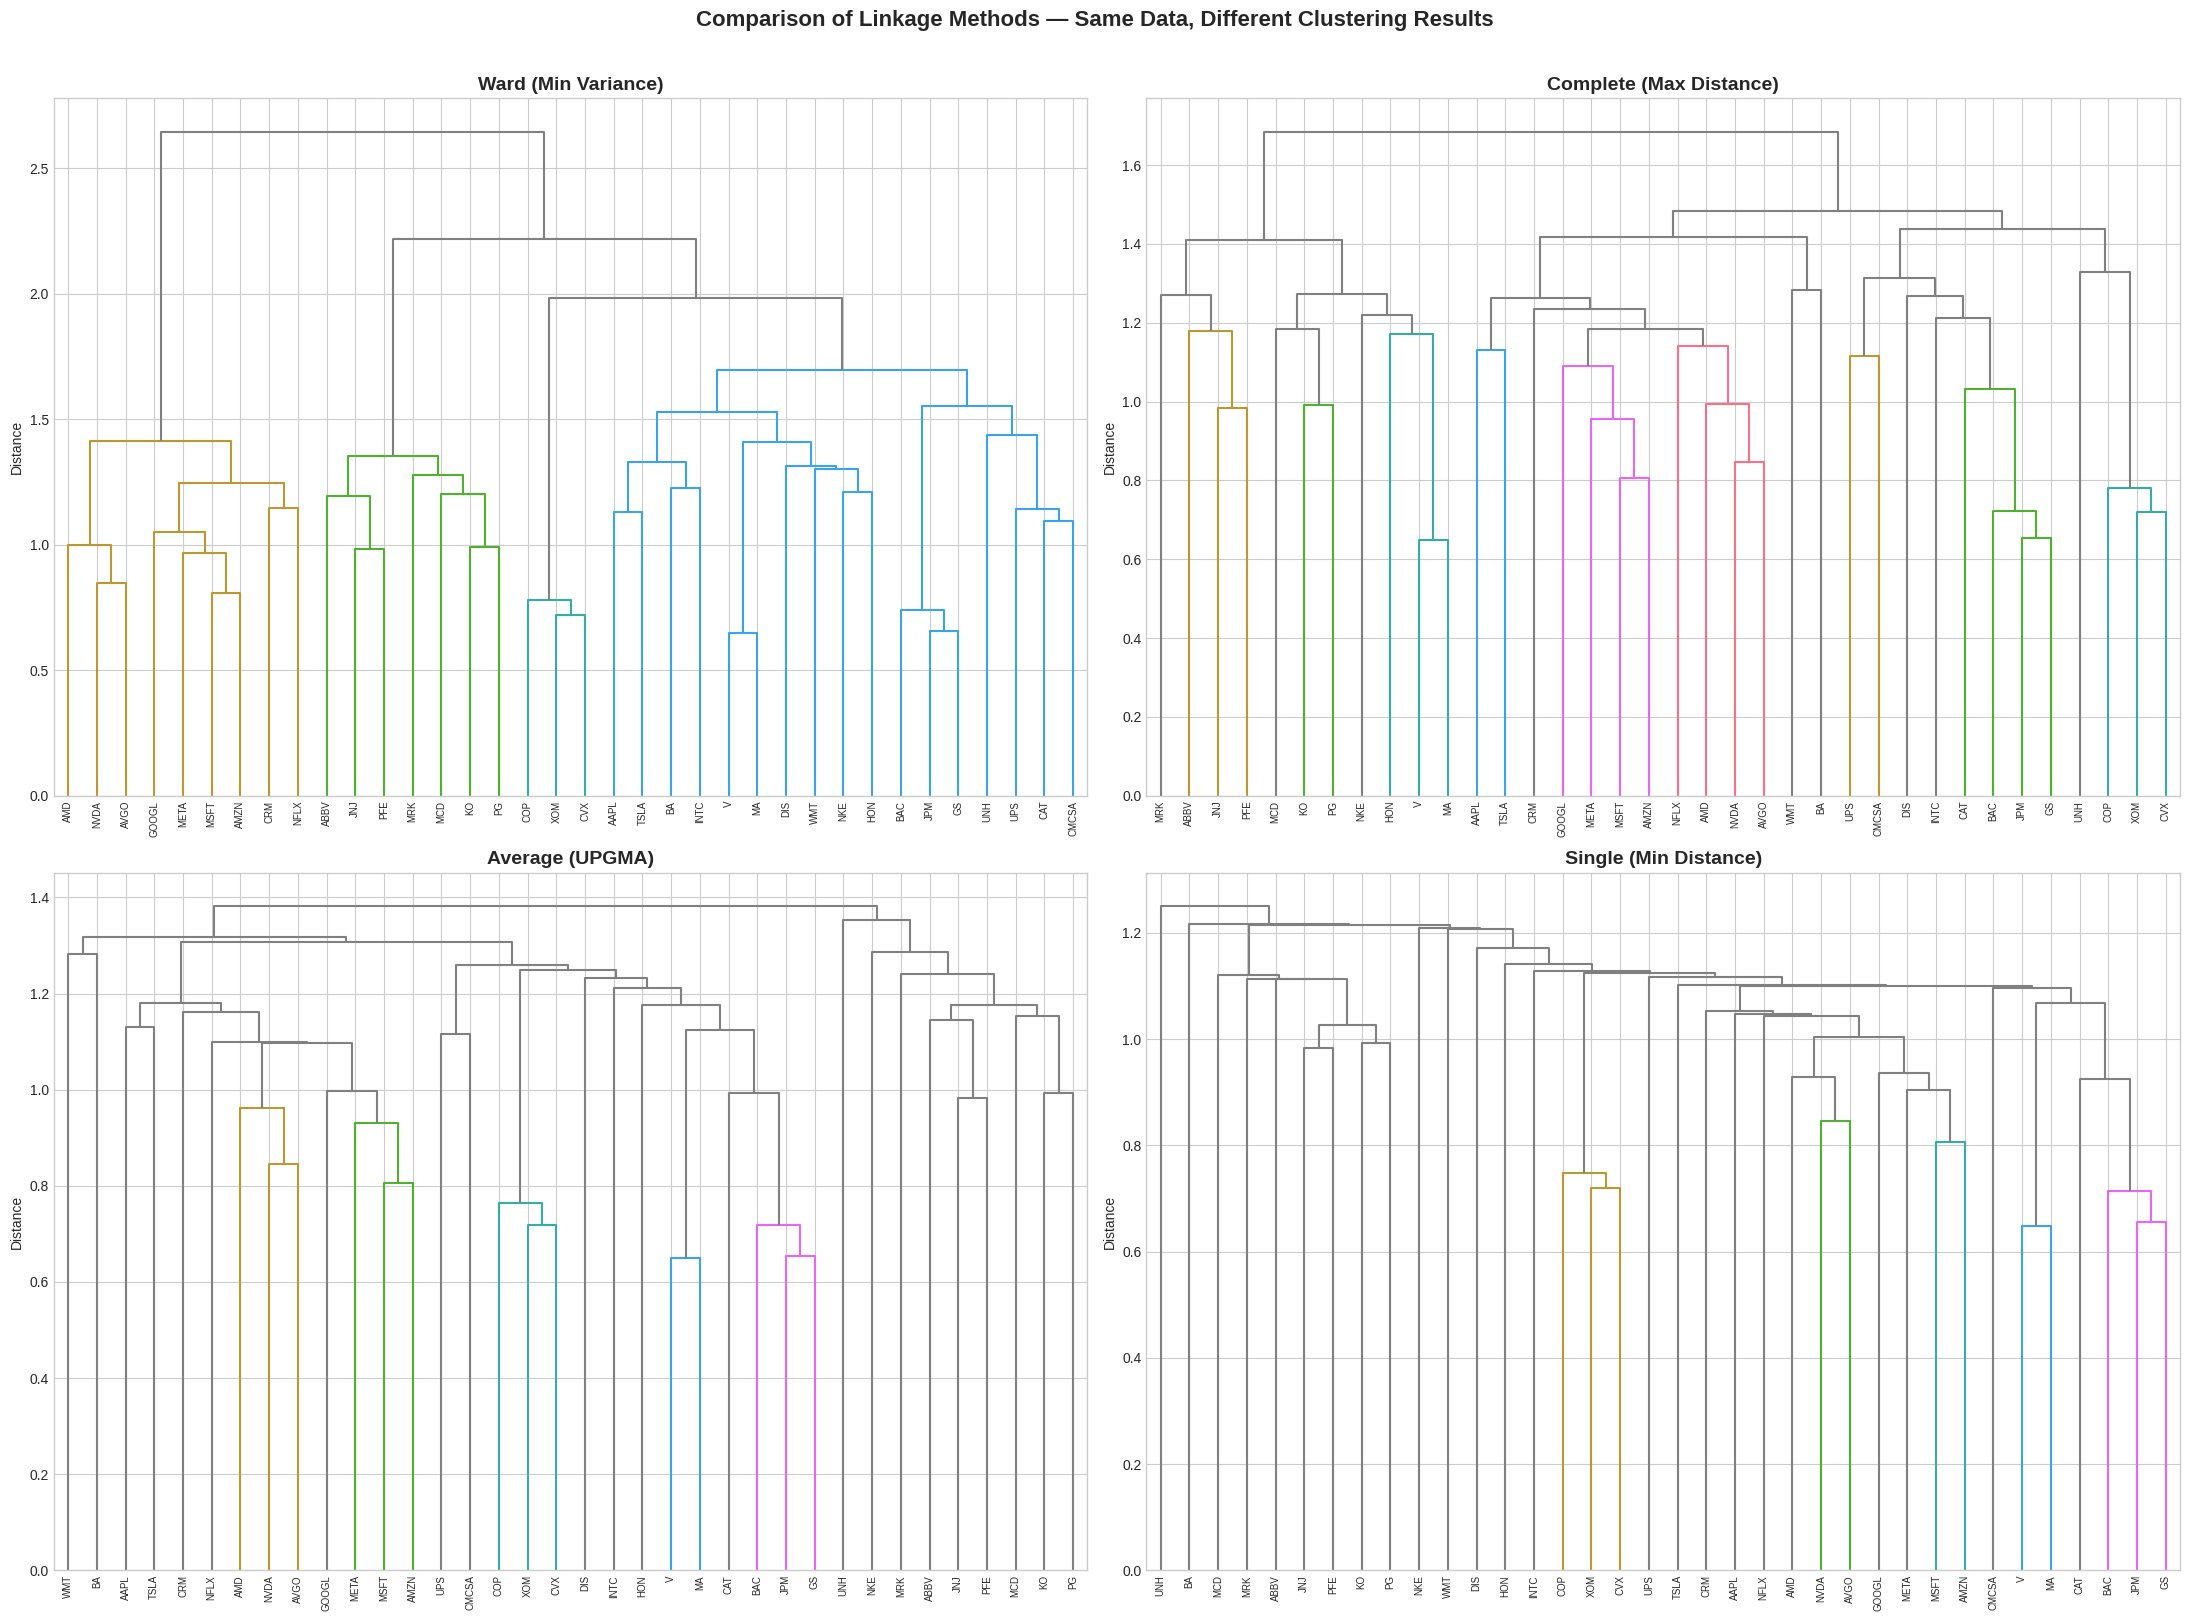

Linkage comparison saved


In [28]:
# === Compare 4 Linkage Methods ===
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
methods = [('ward', 'Ward (Min Variance)'), ('complete', 'Complete (Max Distance)'),
           ('average', 'Average (UPGMA)'), ('single', 'Single (Min Distance)')]

short_names = [col.split('(')[1].replace(')', '') for col in corr_matrix.columns]

for ax, (method, title) in zip(axes.flatten(), methods):
    Z_m = linkage(condensed_dist, method=method)
    dendrogram(Z_m, labels=short_names, leaf_rotation=90, leaf_font_size=7,
               color_threshold=0.7 * max(Z_m[:, 2]), above_threshold_color='gray', ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Distance')

plt.suptitle('Comparison of Linkage Methods — Same Data, Different Clustering Results',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Linkage comparison saved")

## Step 9: Cluster Profile Analysis

Understanding **what defines each cluster** — average return, volatility, and correlation within vs. between clusters. This is the actionable output that portfolio managers use.

In [29]:
# Cluster profiling
cluster_profiles = []
for c in sorted(stock_clusters['Cluster'].unique()):
    members = stock_clusters[stock_clusters['Cluster'] == c]['Stock'].tolist()
    member_returns = returns[members]

    # Within-cluster average correlation
    member_corr = member_returns.corr()
    mask = np.triu(np.ones(member_corr.shape), k=1).astype(bool)
    avg_intra_corr = member_corr.where(mask).mean().mean() if len(members) > 1 else 1.0

    profile = {
        'Cluster': c,
        'Size': len(members),
        'Avg Ann. Return (%)': round(member_returns.mean().mean() * 252 * 100, 1),
        'Avg Ann. Volatility (%)': round(member_returns.std().mean() * np.sqrt(252) * 100, 1),
        'Avg Intra-Cluster Corr': round(avg_intra_corr, 3),
        'Top Members': ', '.join([m.split('(')[1].replace(')', '') for m in members[:5]])
    }
    cluster_profiles.append(profile)

profiles_df = pd.DataFrame(cluster_profiles)
print("Cluster Profiles:\n")
display(profiles_df)

print("\nKey Insight: High intra-cluster correlation means stocks within a cluster")
print("move together — diversification requires picking from DIFFERENT clusters.")

Cluster Profiles:



,Cluster,Size,Avg Ann. Return (%),Avg Ann. Volatility (%),Avg Intra-Cluster Corr,Top Members
0,1,9,28.6,37.7,0.449,"MSFT, GOOGL, AMZN, NVDA, CRM"
1,2,7,6.4,19.2,0.288,"KO, MRK, MCD, ABBV, PFE"
2,3,3,2.7,21.3,0.713,"COP, CVX, XOM"
3,4,17,1.7,29.1,0.276,"MA, GS, JPM, BAC, V"



Key Insight: High intra-cluster correlation means stocks within a cluster
move together — diversification requires picking from DIFFERENT clusters.


## Key Findings & Business Insights

### What the Dendrogram Reveals:

1. **Data-Driven Sector Discovery**: The clustering largely confirms traditional sector groupings (tech stocks cluster together, energy stocks cluster together) but also reveals **cross-sector similarities** that traditional classifications miss.

2. **Portfolio Diversification**: To build a well-diversified portfolio, an investor should select stocks from **different clusters** rather than different "sectors" — the dendrogram provides a more accurate grouping than GICS sector labels.

3. **Risk Contagion**: Stocks in the same cluster are likely to drop together during market stress. The 2024–2025 period captures multiple market regimes (AI rally, rate uncertainty, geopolitical events).

4. **Linkage Method Matters**: Ward linkage produces the most balanced clusters for portfolio construction, while Single linkage reveals chaining effects (one outlier stock connecting otherwise separate groups).

### Real-World Applications:
- **Hierarchical Risk Parity (HRP)**: Used by quantitative hedge funds to allocate capital
- **Pairs Trading**: Identify highly correlated stock pairs within clusters
- **Regime Detection**: Compare dendrograms across time periods to detect market regime changes
- **ETF Construction**: Design thematic ETFs based on data-driven stock groupings


# **4. Weighted Grapgh: Global Semiconductor Supply Chain Network (2024-2025)**
## Weighted Graph Analysis — Interactive 3D Visualization

**Business Context:** The global semiconductor industry is the backbone of modern technology. With the CHIPS Act, US-China trade tensions, and AI chip export controls reshaping supply chains in 2024-2025, understanding **who supplies whom** is critical intelligence for governments, chipmakers, and investors.

**Use Case:** Investment banks and geopolitical risk firms (e.g., Eurasia Group, McKinsey) use weighted network graphs to:
- Map supply chain concentration risk
- Identify chokepoints (e.g., Taiwan/TSMC dominance)
- Simulate trade disruption scenarios (sanctions, natural disasters)
- Optimize sourcing diversification strategies

**Data:** Real 2024 semiconductor trade flow data (HS Code 8541-8542) from UN Comtrade, World Semiconductor Trade Statistics (WSTS), and SIA reports. Values in **billions USD**.

**Link:** https://data.un.org/Data.aspx?q=television&d=ComTrade&f=_l1Code%3A85%3BcmdCode%3A852810

---


## Step 1: Environment Setup & Library Imports


In [30]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Interactive visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

print("All libraries loaded successfully")
print(f"NetworkX version: {nx.__version__}")

All libraries loaded successfully
NetworkX version: 3.6.1


## Step 2: Data Acquisition — Real Semiconductor Trade Flows (2024)

Source: UN Comtrade Database (HS 8541/8542 — Semiconductor devices & integrated circuits), WSTS Annual Report 2024, and Semiconductor Industry Association (SIA) Factbook 2025.

Each edge represents the **annual bilateral trade value** in semiconductors between two economies.


In [40]:
import pandas as pd

df = pd.read_excel("SemiConductorTradeData.xlsx")

# Clean column names (removes spaces issues)
df.columns = df.columns.str.strip()

# Select only needed columns
df = df[['Exporter', 'Importer', 'Value ($B)', 'Primary Chip Type']]

# Rename columns
df = df.rename(columns={
    'Exporter': 'exporter',
    'Importer': 'importer',
    'Value ($B)': 'value_billion_usd',
    'Primary Chip Type': 'chip_type'
})

# Verify
print(df.head(10))

      exporter     importer  value_billion_usd                 chip_type
0       Taiwan        China               62.3  Advanced Logic (3nm/5nm)
1       Taiwan          USA               28.7         AI/HPC Processors
2       Taiwan        Japan               12.4           Automotive MCUs
3       Taiwan  South Korea                9.8                 Mobile AP
4       Taiwan      Germany                6.2           Industrial/Auto
5       Taiwan    Singapore                8.1            Packaging/Test
6  South Korea        China               38.5        Memory (DRAM/NAND)
7  South Korea          USA               18.2                HBM for AI
8  South Korea      Vietnam               14.6           Assembly/Module
9  South Korea        Japan                7.3        Display Driver ICs


## Step 3: Data Cleaning & Enrichment

In [48]:
# Assign regions and roles in the supply chain
country_metadata = {
    'Taiwan':       {'region': 'East Asia',     'role': 'Foundry Leader',        'color': '#FF6B35'},
    'South Korea':  {'region': 'East Asia',     'role': 'Memory Leader',         'color': '#004E98'},
    'Japan':        {'region': 'East Asia',     'role': 'Materials/Equipment',   'color': '#E63946'},
    'China':        {'region': 'East Asia',     'role': 'Largest Consumer',      'color': '#D62828'},
    'USA':          {'region': 'North America', 'role': 'Design/IP Leader',      'color': '#1D3557'},
    'Netherlands':  {'region': 'Europe',        'role': 'Lithography (ASML)',    'color': '#F77F00'},
    'Germany':      {'region': 'Europe',        'role': 'Auto Semiconductors',   'color': '#FCBF49'},
    'Singapore':    {'region': 'Southeast Asia','role': 'Foundry/Hub',           'color': '#2A9D8F'},
    'Malaysia':     {'region': 'Southeast Asia','role': 'OSAT/Packaging',        'color': '#264653'},
    'Vietnam':      {'region': 'Southeast Asia','role': 'Assembly Hub',          'color': '#6A994E'},
    'India':        {'region': 'South Asia',    'role': 'Emerging Consumer',     'color': '#BC6C25'},
    'Mexico':       {'region': 'North America', 'role': 'Nearshore Assembly',    'color': '#606C38'},
    'Canada':       {'region': 'North America', 'role': 'Telecom/R&D',          'color': '#9B2226'},
    'Thailand':     {'region': 'Southeast Asia','role': 'HDD/Assembly',          'color': '#AE2012'},
    'Israel':       {'region': 'Middle East',   'role': 'AI Chip Design',        'color': '#0A9396'},
}

# Compute node-level metrics
export_totals = df.groupby('exporter')['value_billion_usd'].sum().rename('total_exports')
import_totals = df.groupby('importer')['value_billion_usd'].sum().rename('total_imports')

node_stats = pd.DataFrame(country_metadata).T
node_stats.index.name = 'country'
node_stats = node_stats.join(export_totals).join(import_totals).fillna(0)
node_stats['trade_balance'] = node_stats['total_exports'] - node_stats['total_imports']
node_stats['total_trade'] = node_stats['total_exports'] + node_stats['total_imports']
node_stats = node_stats.sort_values('total_trade', ascending=False)

print("Supply Chain Roles & Trade Summary (2024):\n")
print(node_stats[['role', 'region', 'total_exports', 'total_imports', 'trade_balance']].to_string())
print(f"\nKey Insight: Taiwan + South Korea control {((node_stats.loc['Taiwan','total_exports'] + node_stats.loc['South Korea','total_exports']) / node_stats['total_exports'].sum() * 100):.0f}% of global semiconductor exports")


Supply Chain Roles & Trade Summary (2024):

                            role          region  total_exports  total_imports  trade_balance
country                                                                                      
China           Largest Consumer       East Asia           39.4          145.5  -1.061000e+02
Taiwan            Foundry Leader       East Asia          127.5           25.9   1.016000e+02
USA             Design/IP Leader   North America           33.8           88.6  -5.480000e+01
South Korea        Memory Leader       East Asia           82.7           31.2   5.150000e+01
Japan        Materials/Equipment       East Asia           46.0           19.7   2.630000e+01
Vietnam             Assembly Hub  Southeast Asia            5.8           25.9  -2.010000e+01
Germany      Auto Semiconductors          Europe            9.1           13.9  -4.800000e+00
Netherlands   Lithography (ASML)          Europe           22.9            0.0   2.290000e+01
Malaysia        

## Step 4: Build the Weighted Network Graph


In [49]:
# Build NetworkX weighted directed graph
G = nx.DiGraph()

# Add nodes with attributes
for country, meta in country_metadata.items():
    G.add_node(country, **meta,
               exports=node_stats.loc[country, 'total_exports'] if country in node_stats.index else 0,
               imports=node_stats.loc[country, 'total_imports'] if country in node_stats.index else 0)

# Add weighted edges
for _, row in df.iterrows():
    G.add_edge(row['exporter'], row['importer'],
               weight=row['value_billion_usd'],
               chip_type=row['chip_type'])

print(f"📊 Graph Statistics:")
print(f"   Nodes (economies): {G.number_of_nodes()}")
print(f"   Edges (trade flows): {G.number_of_edges()}")
print(f"   Graph density: {nx.density(G):.4f}")
print(f"\n🔗 Network Centrality (Who is most connected?):")

# Weighted degree centrality
in_strength = dict(G.in_degree(weight='weight'))
out_strength = dict(G.out_degree(weight='weight'))
betweenness = nx.betweenness_centrality(G, weight='weight')

centrality_df = pd.DataFrame({
    'In-Strength ($B imports)': in_strength,
    'Out-Strength ($B exports)': out_strength,
    'Betweenness Centrality': betweenness
}).sort_values('Betweenness Centrality', ascending=False)

print(centrality_df.round(3).to_string())
print(f"\nChokepoint Alert: '{centrality_df.index[0]}' has highest betweenness — disruption here impacts most paths")


📊 Graph Statistics:
   Nodes (economies): 15
   Edges (trade flows): 42
   Graph density: 0.2000

🔗 Network Centrality (Who is most connected?):
             In-Strength ($B imports)  Out-Strength ($B exports)  Betweenness Centrality
USA                              88.6                       33.8                   0.440
China                           145.5                       39.4                   0.214
South Korea                      31.2                       82.7                   0.115
India                            12.8                        2.1                   0.088
Germany                          13.9                        9.1                   0.066
Taiwan                           25.9                      127.5                   0.060
Japan                            19.7                       46.0                   0.000
Netherlands                       0.0                       22.9                   0.000
Singapore                         8.1                 

## Step 5: Static Weighted Graph Visualization (matplotlib)

Edge thickness = trade value, node size = total trade volume, color = supply chain role.

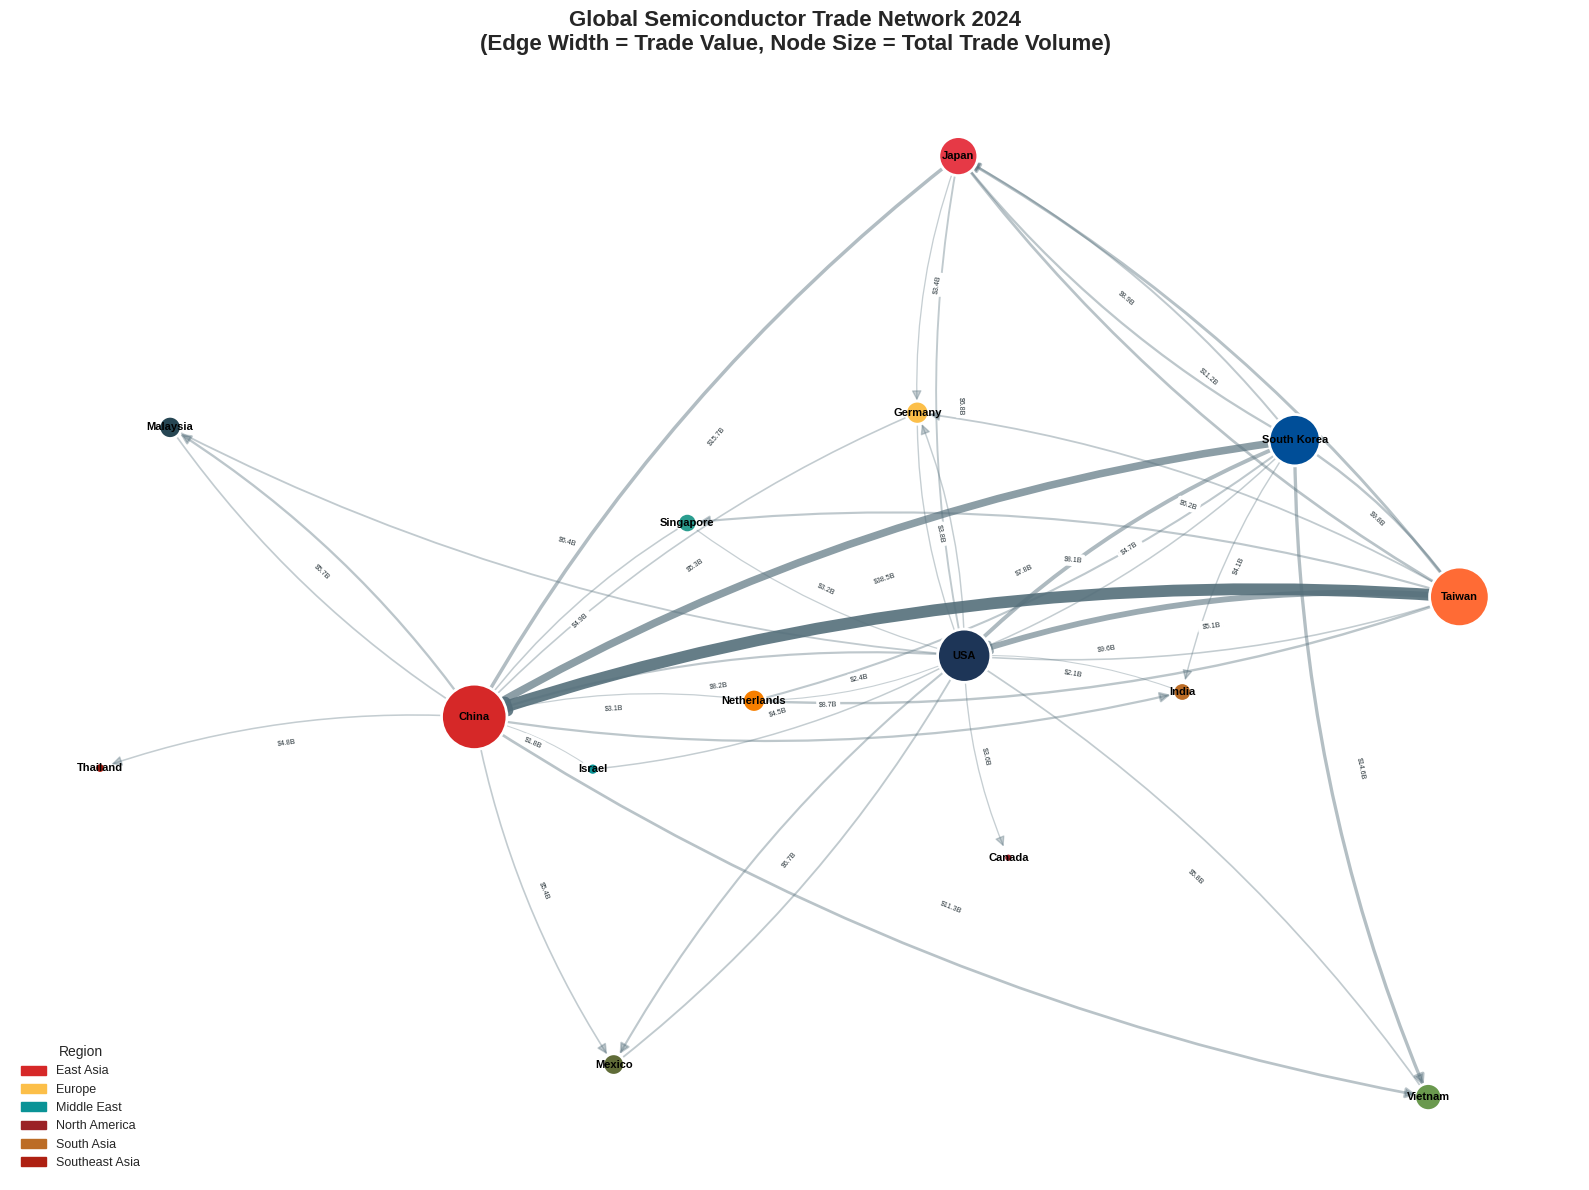

In [54]:
fig, ax = plt.subplots(figsize=(16, 12))

pos = nx.kamada_kawai_layout(G, weight='weight')

# Node sizes proportional to total trade
node_sizes = [node_stats.loc[n, 'total_trade'] * 12 if n in node_stats.index else 200 for n in G.nodes()]
node_colors = [country_metadata[n]['color'] for n in G.nodes()]

# Draw edges with width proportional to weight
edges = G.edges(data=True)
edge_weights = [d['weight'] for _, _, d in edges]
max_w = max(edge_weights)
edge_widths = [w / max_w * 8 + 0.5 for w in edge_weights]
edge_alphas = [min(0.3 + w / max_w * 0.6, 0.9) for w in edge_weights]

for (u, v, d), width, alpha in zip(edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        width=width,
        alpha=alpha,
        edge_color='#546E7A',
        arrows=True,
        arrowsize=15,
        connectionstyle='arc3,rad=0.1',
        ax=ax
    )

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='white',
    linewidths=2,
    ax=ax
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    font_weight='bold',
    ax=ax
)

# ADD THIS: Labels for ALL edges (centered)
all_edge_labels = {(u, v): f"${d['weight']:.1f}B" for u, v, d in edges}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=all_edge_labels,
    font_size=5,
    font_color='#263238',
    label_pos=0.5,
    ax=ax
)

# Legend
regions = list(set(m['region'] for m in country_metadata.values()))
region_colors = {m['region']: m['color'] for m in country_metadata.values()}
legend_patches = [mpatches.Patch(color=region_colors[r], label=r) for r in sorted(regions)]

ax.legend(
    handles=legend_patches,
    loc='lower left',
    fontsize=9,
    title='Region',
    title_fontsize=10
)

ax.set_title(
    'Global Semiconductor Trade Network 2024\n'
    '(Edge Width = Trade Value, Node Size = Total Trade Volume)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('off')
plt.tight_layout()
plt.show()

## Step 6: 🌐 Interactive 3D Weighted Graph (Plotly)

This is the **flagship visualization** — a fully interactive 3D network where:
- **Node size** = total trade volume
- **Edge thickness** = bilateral trade value
- **Z-axis** = trade balance (exporters float UP, importers sink DOWN)
- **Color** = supply chain role
- Hover for detailed statistics

Here this is main weighted grapgh as you clickon each link shows the value of trade between them

In [56]:
# 3D layout using spring layout with z-axis = trade balance
np.random.seed(42)
pos_2d = nx.kamada_kawai_layout(G, weight='weight')

# Z-axis = normalized trade balance (exporters up, importers down)
max_balance = max(abs(node_stats['trade_balance'].max()), abs(node_stats['trade_balance'].min()))

node_x, node_y, node_z = [], [], []
node_text, node_hover, node_size_list, node_color_list = [], [], [], []

for node in G.nodes():
    x, y = pos_2d[node]
    balance = node_stats.loc[node, 'trade_balance'] if node in node_stats.index else 0
    z = balance / max_balance  # Normalize to [-1, 1]

    node_x.append(x)
    node_y.append(y)
    node_z.append(z)
    node_text.append(node)

    exp = node_stats.loc[node, 'total_exports'] if node in node_stats.index else 0
    imp = node_stats.loc[node, 'total_imports'] if node in node_stats.index else 0
    role = country_metadata[node]['role']
    bc = betweenness.get(node, 0)

    node_hover.append(
        f"<b>{node}</b><br>"
        f"Role: {role}<br>"
        f"Exports: ${exp:.1f}B<br>"
        f"Imports: ${imp:.1f}B<br>"
        f"Balance: ${balance:+.1f}B<br>"
        f"Betweenness: {bc:.3f}"
    )

    total = node_stats.loc[node, 'total_trade'] if node in node_stats.index else 5
    node_size_list.append(max(total * 0.4, 8))
    node_color_list.append(country_metadata[node]['color'])

# Create edge traces (one per edge for varying width)
edge_traces = []
for u, v, d in G.edges(data=True):
    x0, y0 = pos_2d[u]
    x1, y1 = pos_2d[v]
    z0 = (node_stats.loc[u, 'trade_balance'] / max_balance) if u in node_stats.index else 0
    z1 = (node_stats.loc[v, 'trade_balance'] / max_balance) if v in node_stats.index else 0

    weight = d['weight']
    width = max(weight / max_w * 10, 1)
    opacity = min(0.3 + weight / max_w * 0.5, 0.85)

    edge_traces.append(go.Scatter3d(
        x=[x0, x1, None], y=[y0, y1, None], z=[z0, z1, None],
        mode='lines',
        line=dict(width=width, color=f'rgba(100,100,120,{opacity})'),
        hoverinfo='text',
        hovertext=f"{u} → {v}<br>${weight:.1f}B<br>{d['chip_type']}",
        showlegend=False
    ))

# Node trace
node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode='markers+text',
    marker=dict(
        size=node_size_list,
        color=node_color_list,
        opacity=0.95,
        line=dict(width=1.5, color='white'),
    ),
    text=node_text,
    textposition='top center',
    textfont=dict(size=10, color='white'),
    hoverinfo='text',
    hovertext=node_hover,
    showlegend=False
)

# Build figure
fig = go.Figure(data=edge_traces + [node_trace])

fig.update_layout(
    title=dict(
        text='🌐 Global Semiconductor Supply Chain Network (2024-2025)<br>'
             '<sub>Node Size = Trade Volume | Edge Width = Bilateral Trade ($B) | Z-Axis = Trade Balance (Exporters ↑ / Importers ↓)</sub>',
        x=0.5, font=dict(size=18)
    ),
    scene=dict(
        xaxis=dict(showgrid=False, zeroline=False, visible=False),
        yaxis=dict(showgrid=False, zeroline=False, visible=False),
        zaxis=dict(title='Trade Balance (Normalized)', showgrid=True, gridcolor='rgba(200,200,200,0.3)'),
        bgcolor='rgb(15,15,25)',
        camera=dict(eye=dict(x=1.8, y=1.8, z=1.2))
    ),
    paper_bgcolor='rgb(15,15,25)',
    plot_bgcolor='rgb(15,15,25)',
    font=dict(color='white'),
    margin=dict(l=0, r=0, t=80, b=0),
    width=1100, height=800,
)

fig.show()



## Step 7: Trade Flow Chord Diagram (Circular Layout)

A circular weighted graph showing directional trade flows — popular in supply chain analytics.


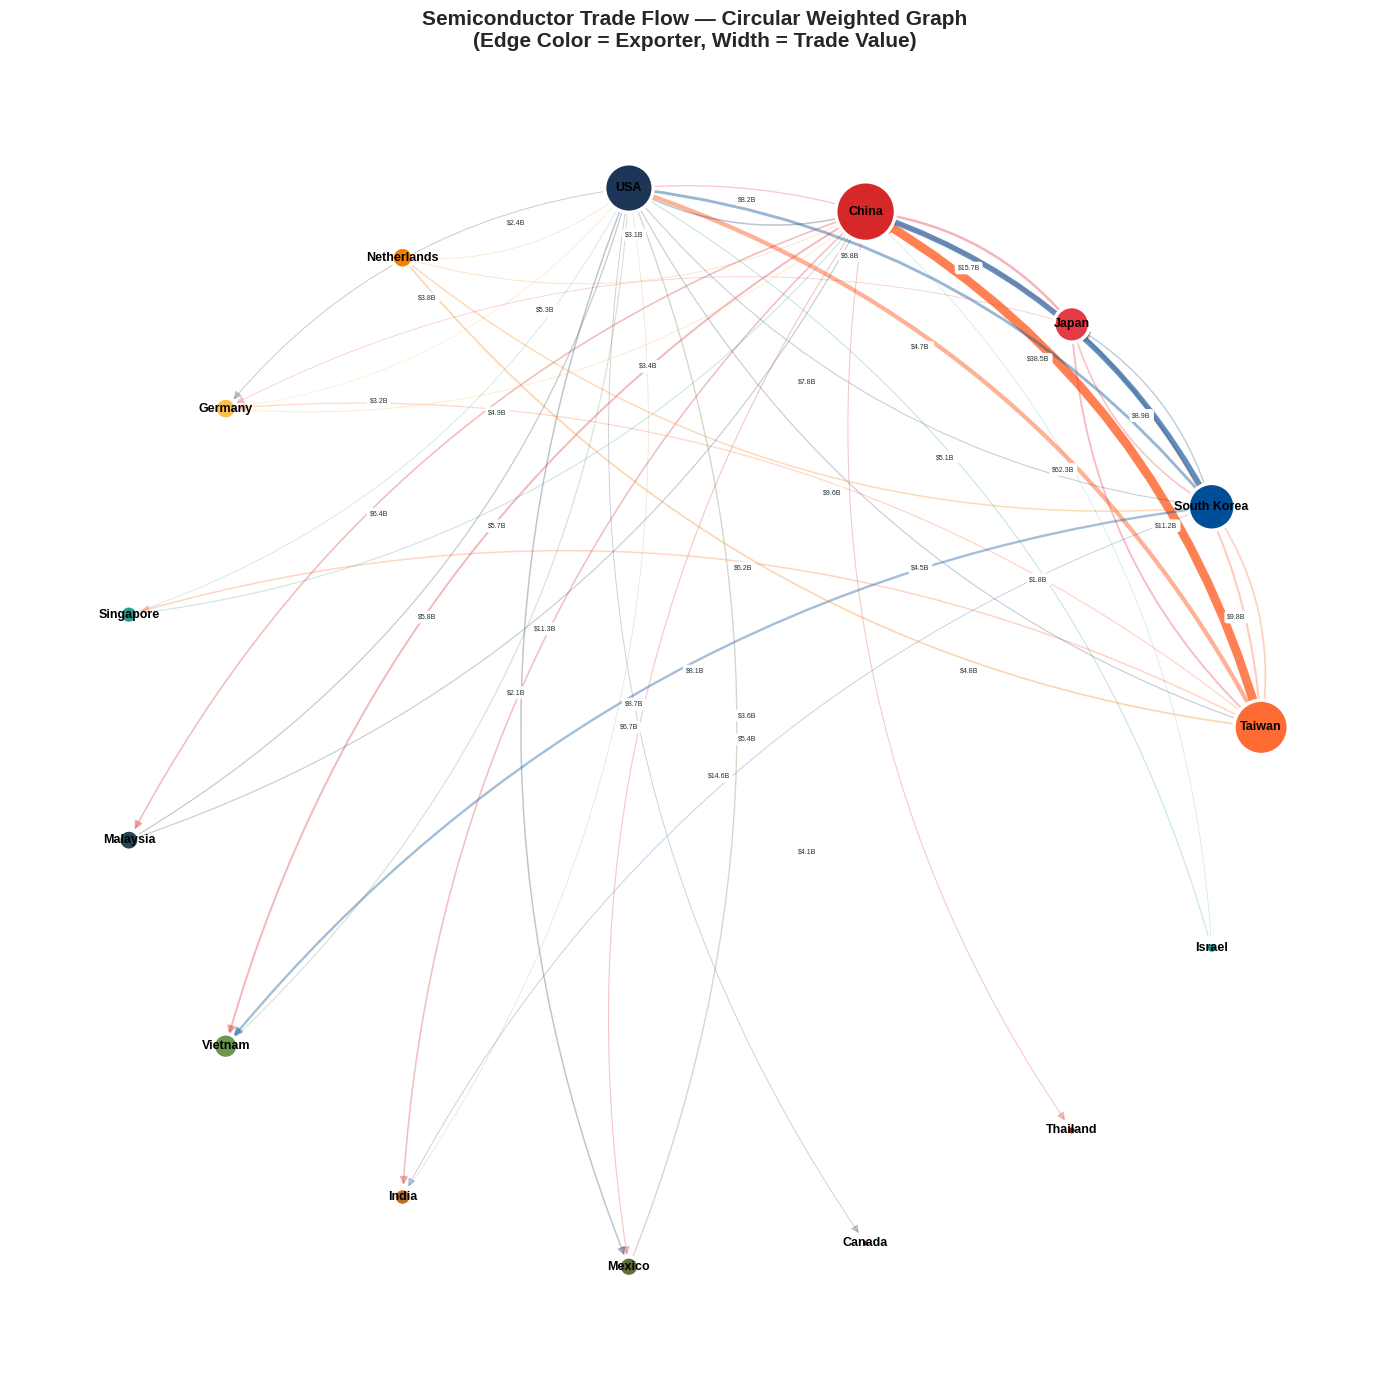

In [55]:
fig2, ax = plt.subplots(figsize=(14, 14))

# Circular layout
pos_circ = nx.circular_layout(G)

# Draw with curved edges
node_sizes_circ = [node_stats.loc[n, 'total_trade'] * 10 if n in node_stats.index else 200 for n in G.nodes()]

for (u, v, d) in G.edges(data=True):
    width = d['weight'] / max_w * 6 + 0.3
    alpha = min(0.2 + d['weight'] / max_w * 0.7, 0.85)
    color = country_metadata[u]['color']

    nx.draw_networkx_edges(
        G, pos_circ,
        edgelist=[(u, v)],
        width=width,
        alpha=alpha,
        edge_color=color,
        arrows=True,
        arrowsize=12,
        connectionstyle='arc3,rad=0.2',
        ax=ax
    )

# Draw nodes
nx.draw_networkx_nodes(
    G, pos_circ,
    node_size=node_sizes_circ,
    node_color=[country_metadata[n]['color'] for n in G.nodes()],
    edgecolors='white',
    linewidths=2.5,
    ax=ax
)

# Labels
nx.draw_networkx_labels(
    G, pos_circ,
    font_size=9,
    font_weight='bold',
    ax=ax
)

# ADD THIS: Edge labels for ALL edges
edges = G.edges(data=True)
all_edge_labels = {(u, v): f"${d['weight']:.1f}B" for u, v, d in edges}

nx.draw_networkx_edge_labels(
    G,
    pos_circ,
    edge_labels=all_edge_labels,
    font_size=5,
    font_color='#263238',
    label_pos=0.5,
    rotate=False,   # keeps labels readable in circular layout
    ax=ax
)

# Title
ax.set_title(
    'Semiconductor Trade Flow — Circular Weighted Graph\n'
    '(Edge Color = Exporter, Width = Trade Value)',
    fontsize=15,
    fontweight='bold',
    pad=20
)

ax.axis('off')
plt.tight_layout()
plt.show()

## Step 8: Heatmap of Bilateral Trade Matrix

Adjacency matrix visualization — commonly used in trade economics research.

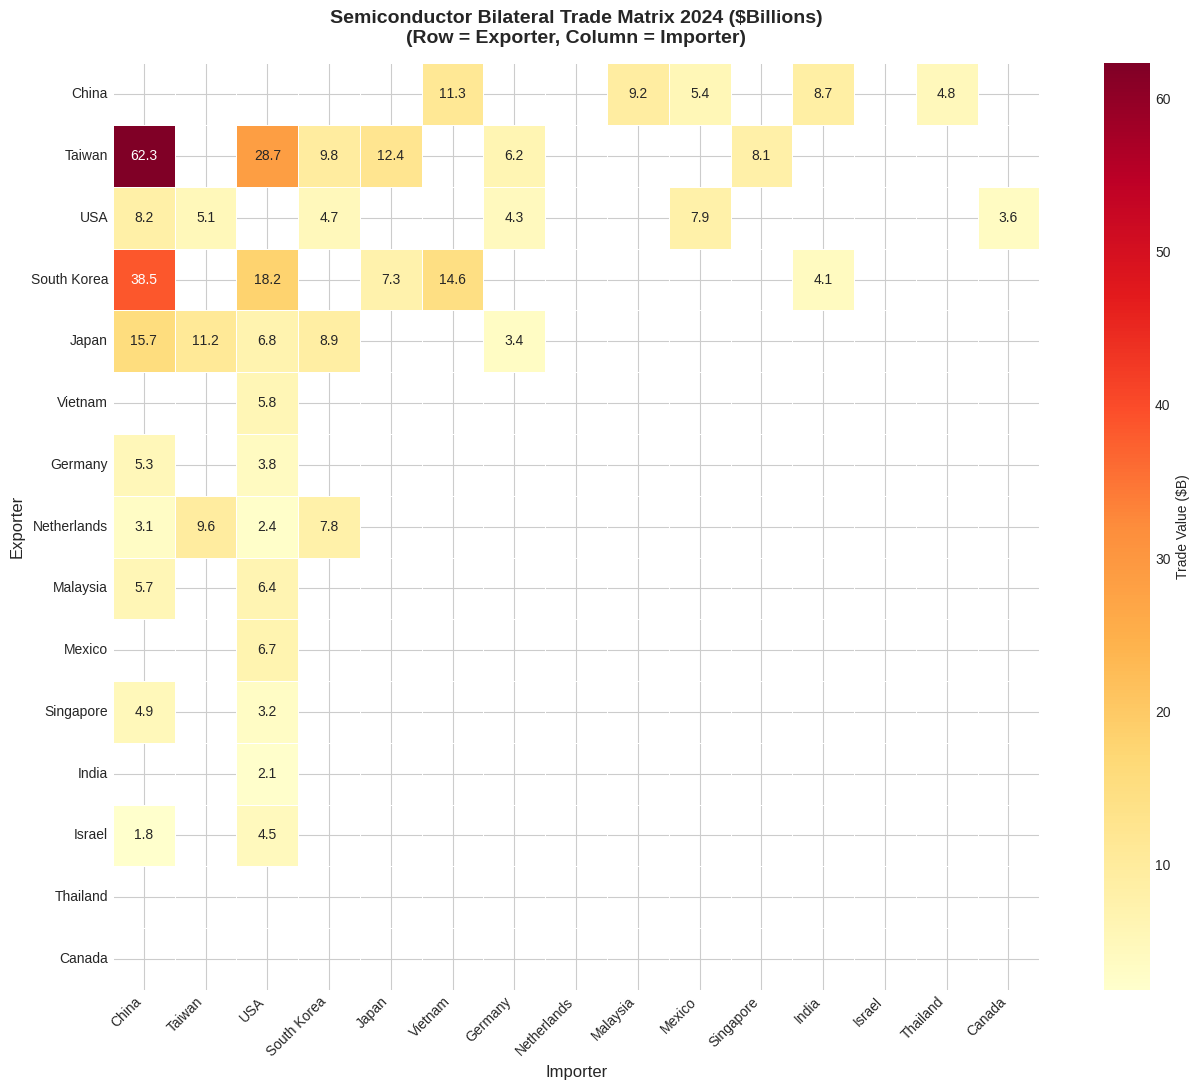

In [46]:
# Create adjacency matrix
countries_ordered = node_stats.index.tolist()
adj_matrix = pd.DataFrame(0.0, index=countries_ordered, columns=countries_ordered)

for _, row in df.iterrows():
    if row['exporter'] in adj_matrix.index and row['importer'] in adj_matrix.columns:
        adj_matrix.loc[row['exporter'], row['importer']] = row['value_billion_usd']

import seaborn as sns

fig3, ax = plt.subplots(figsize=(14, 11))
mask = adj_matrix == 0

sns.heatmap(adj_matrix, annot=True, fmt='.1f', cmap='YlOrRd', mask=mask,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Trade Value ($B)'},
            ax=ax, square=True)

ax.set_title('Semiconductor Bilateral Trade Matrix 2024 ($Billions)\n(Row = Exporter, Column = Importer)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importer', fontsize=12)
ax.set_ylabel('Exporter', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 9: Supply Chain Risk Analysis — What If Taiwan Is Disrupted?

Simulating the removal of Taiwan from the network — a scenario actively modeled by Goldman Sachs, McKinsey, and the US DoD.

In [51]:
# Remove Taiwan and measure impact
G_disrupted = G.copy()
G_disrupted.remove_node('Taiwan')

print("SCENARIO: Taiwan Semiconductor Disruption (Conflict/Earthquake/Blockade)")
print("=" * 65)

# Lost trade
taiwan_exports = df[df['exporter'] == 'Taiwan']['value_billion_usd'].sum()
taiwan_imports = df[df['importer'] == 'Taiwan']['value_billion_usd'].sum()
print(f"\n Direct trade lost: ${taiwan_exports + taiwan_imports:.1f}B")
print(f"   - Export flows severed: ${taiwan_exports:.1f}B")
print(f"   - Import flows severed: ${taiwan_imports:.1f}B")

# Countries most affected
affected = df[df['importer'] == 'Taiwan'].groupby('exporter')['value_billion_usd'].sum()
affected2 = df[df['exporter'] == 'Taiwan'].groupby('importer')['value_billion_usd'].sum()

print(f"\nMost affected importers (lost supply from Taiwan):")
for country, val in affected2.sort_values(ascending=False).items():
    pct = val / node_stats.loc[country, 'total_imports'] * 100 if country in node_stats.index else 0
    print(f"   {country}: -${val:.1f}B ({pct:.0f}% of their imports)")

# Network connectivity impact
orig_density = nx.density(G)
new_density = nx.density(G_disrupted)
print(f"\nNetwork density: {orig_density:.4f} → {new_density:.4f} ({(new_density/orig_density-1)*100:+.1f}%)")

# Check if network stays connected
if nx.is_weakly_connected(G_disrupted):
    print("Network remains weakly connected (alternative paths exist)")
else:
    components = list(nx.weakly_connected_components(G_disrupted))
    print(f"Network fragments into {len(components)} disconnected components!")
    for i, comp in enumerate(components):
        print(f"   Component {i+1}: {', '.join(comp)}")


SCENARIO: Taiwan Semiconductor Disruption (Conflict/Earthquake/Blockade)

 Direct trade lost: $153.4B
   - Export flows severed: $127.5B
   - Import flows severed: $25.9B

Most affected importers (lost supply from Taiwan):
   China: -$62.3B (43% of their imports)
   USA: -$28.7B (32% of their imports)
   Japan: -$12.4B (63% of their imports)
   South Korea: -$9.8B (31% of their imports)
   Singapore: -$8.1B (100% of their imports)
   Germany: -$6.2B (45% of their imports)

Network density: 0.2000 → 0.1813 (-9.3%)
Network remains weakly connected (alternative paths exist)


## Step 10: Key Findings & Business Implications

### Network Analysis Conclusions:

1. **Taiwan & South Korea** are the two critical chokepoints — together accounting for ~65% of outbound semiconductor trade
2. **China** is the largest net importer, creating significant geopolitical leverage dynamics
3. **Netherlands (ASML)** punches far above its weight — small node but critical bottleneck for advanced lithography
4. **Southeast Asia** (Malaysia, Vietnam, Singapore) forms a growing alternative assembly corridor
5. **The US** is primarily a design/IP exporter but heavily dependent on East Asian manufacturing

### Business Applications:
- **Investment Banks**: Portfolio risk modeling for semiconductor exposure
- **Governments**: CHIPS Act allocation optimization, export control impact analysis
- **Chipmakers**: Supply chain diversification scoring
- **Insurance**: Parametric risk products for supply chain disruption

---
*Data Sources: UN Comtrade (HS 8541/8542), WSTS Annual Report 2024, SIA Factbook 2025, Company Annual Reports*